<a href="https://colab.research.google.com/github/inigo99/CancerDetection/blob/main/TFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM Detección de cáncer en mamografías

Íñigo Fernández Barrill

### Introducción

In [1]:
from IPython.display import clear_output

!wget https://unirioja-my.sharepoint.com/:u:/g/personal/infernb_unirioja_es/EbUEV-DxkwdClaZ4O8w6tOQB727Kg1Q9cQzyheUb7NddSA?download=1 -O Mamografias.zip
!unzip Mamografias.zip
clear_output()

In [2]:
!pip install fastai -Uq
!pip install timm -Uq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.8 MB/s eta 0:00:00


In [3]:
from fastai.vision.all import *
import timm

path = Path('rsna-breast-cancer-detection_reducido_v2/')
imagesPath = path/'train_images'

In [4]:
import pandas as pd

df = pd.read_csv("rsna-breast-cancer-detection_reducido_v2/train.csv")

In [5]:
def cadena(path):
    partes = path.split(os.path.sep)
    return partes[-1][:-4]

def label_func(fname):
    return df.loc[df['image_id'] == int(cadena(fname.name))]['cancer'].values[0]

## Modelos

### Resnet 50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=128)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='modelResnet50')  
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.004365158267319202)

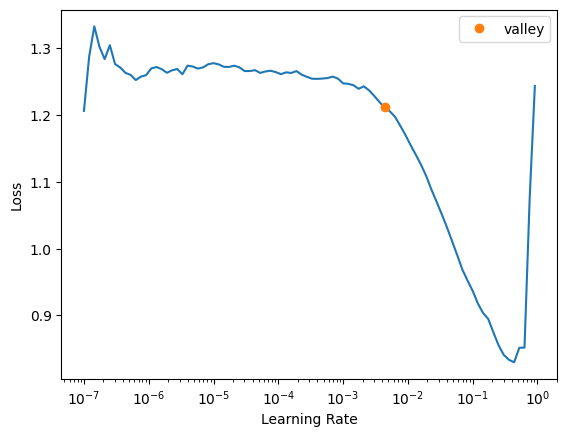

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.134718,0.111616,0.977699,0.000000,0.000000,0.000000,08:48


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.11161649227142334.


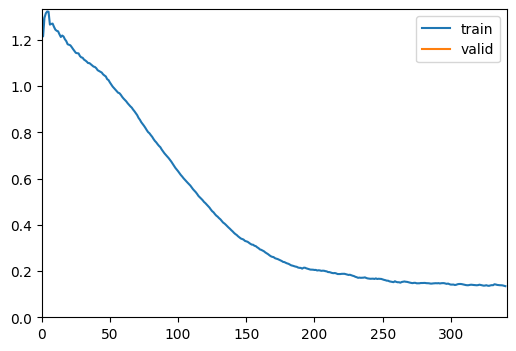

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.105737,0.135013,0.977699,0.000000,0.000000,0.000000,09:04
1,0.113950,0.282286,0.977699,0.000000,0.000000,0.000000,09:04
2,0.112792,0.106755,0.977699,0.000000,0.000000,0.000000,09:10
3,0.099973,0.108033,0.977699,0.000000,0.000000,0.000000,09:09
4,0.098181,0.109675,0.977699,0.000000,0.000000,0.000000,09:02
5,0.098691,0.103121,0.977699,0.000000,0.000000,0.000000,08:51
6,0.096698,0.097624,0.977699,0.500000,0.004098,0.008130,08:40
7,0.089409,0.101533,0.977424,0.440000,0.045082,0.081784,08:49
8,0.088965,0.099235,0.977333,0.437500,0.057377,0.101449,09:03
9,0.088852,0.097297,0.977699,0.500000,0.036885,0.068702,08:59


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.1350134015083313.


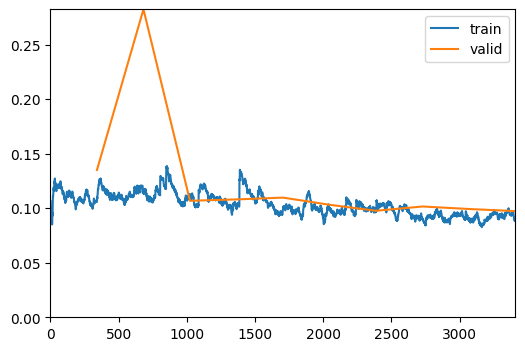

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.10675548017024994.


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.10312093794345856.
Better model found at epoch 6 with valid_loss value: 0.09762357920408249.
Better model found at epoch 9 with valid_loss value: 0.09729737788438797.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 40 mins.

### EfficientNet

Para que la ejecució quepa en la caché, hay que reducir los tamaños de las imágenes y el batch.

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=64)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='efficientNetB3')  
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [ ]:
import torch
torch.cuda.empty_cache()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.157429,0.123083,0.979527,0.000000,0.000000,0.000000,09:34


Better model found at epoch 0 with valid_loss value: 0.12308338284492493.


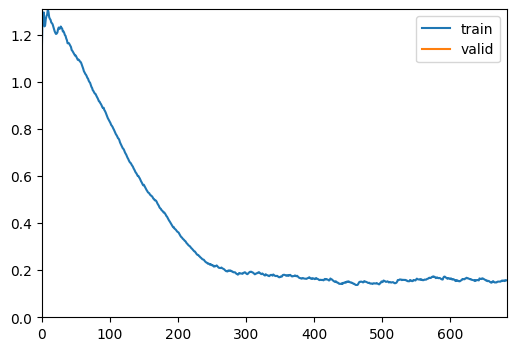

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.109194,0.098137,0.980441,0.000000,0.000000,0.000000,09:29
1,0.114298,0.099628,0.980441,0.000000,0.000000,0.000000,09:19
2,0.125833,0.099406,0.980441,0.000000,0.000000,0.000000,09:17
3,0.109041,0.095146,0.980441,0.000000,0.000000,0.000000,09:16
4,0.103849,0.098076,0.980441,0.000000,0.000000,0.000000,09:19
5,0.088844,0.095915,0.980441,0.000000,0.000000,0.000000,09:19
6,0.107047,nan,0.980441,0.000000,0.000000,0.000000,09:19
7,0.106938,nan,0.980441,0.000000,0.000000,0.000000,09:28
8,0.091529,0.092460,0.980441,0.000000,0.000000,0.000000,09:36
9,0.101932,0.092285,0.980441,0.000000,0.000000,0.000000,09:33


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.09813690185546875.


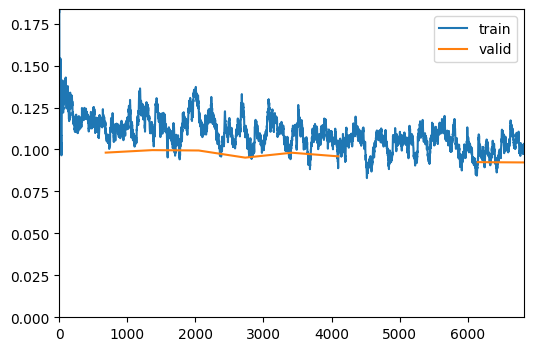

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.09514576196670532.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defin

Better model found at epoch 8 with valid_loss value: 0.09245970100164413.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 9 with valid_loss value: 0.09228470921516418.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 44 mins.

### ConvNext

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='ConvNext')  
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=64)

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:07<00:00, 45.9MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.154840,0.114093,0.980258,0.000000,0.000000,0.000000,09:11


Better model found at epoch 0 with valid_loss value: 0.11409283429384232.


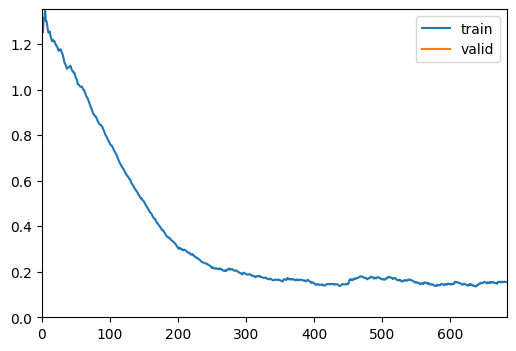

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.097386,0.097244,0.980441,0.000000,0.000000,0.000000,09:37
1,0.124461,0.116928,0.980441,0.000000,0.000000,0.000000,09:37
2,0.101866,0.100506,0.980441,0.000000,0.000000,0.000000,09:35
3,0.108117,0.091792,0.980441,0.000000,0.000000,0.000000,09:36
4,0.100571,0.094839,0.980441,0.000000,0.000000,0.000000,09:36
5,0.107470,0.090112,0.980441,0.000000,0.000000,0.000000,09:37
6,0.107873,0.088212,0.980898,0.857143,0.028037,0.054299,09:39
7,0.106709,0.086807,0.980532,0.538462,0.032710,0.061674,09:30
8,0.096510,0.085968,0.980898,0.857143,0.028037,0.054299,09:29
9,0.099173,0.086072,0.980623,0.600000,0.028037,0.053571,09:28


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.09724444150924683.


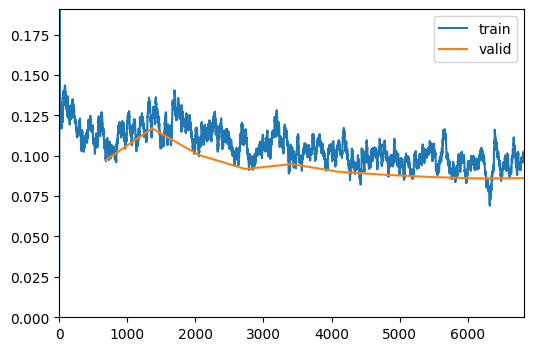

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.09179195761680603.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.09011197090148926.
Better model found at epoch 6 with valid_loss value: 0.08821216225624084.
Better model found at epoch 7 with valid_loss value: 0.08680716902017593.
Better model found at epoch 8 with valid_loss value: 0.08596846461296082.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 45 mins.

### Hrnet

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Hrnet')  
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=32)

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-hrnet/hrnetv2_w44-c9ac8c18.pth" to /root/.cache/torch/hub/checkpoints/hrnetv2_w44-c9ac8c18.pth


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.144876,0.131406,0.976236,0.000000,0.000000,0.000000,12:44


Better model found at epoch 0 with valid_loss value: 0.13140591979026794.


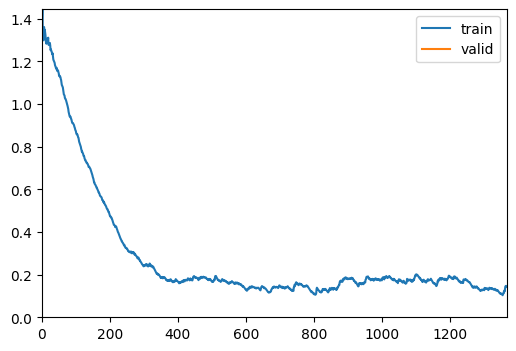

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.099613,0.123273,0.976328,0.000000,0.000000,0.000000,14:00
1,0.126929,0.126066,0.976328,0.000000,0.000000,0.000000,14:00
2,0.118984,0.112464,0.976328,0.000000,0.000000,0.000000,14:10
3,0.114417,0.116200,0.976328,0.000000,0.000000,0.000000,13:59
4,0.103200,0.240522,0.974043,0.000000,0.000000,0.000000,13:58
5,0.095524,1.490318,0.974500,0.000000,0.000000,0.000000,13:55
6,0.101700,nan,0.976328,0.000000,0.000000,0.000000,13:54
7,0.073411,nan,0.976510,0.625000,0.019305,0.037453,13:52
8,0.094232,0.105128,0.976419,0.555556,0.019305,0.037313,13:52
9,0.097534,nan,0.976510,0.625000,0.019305,0.037453,13:50


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.12327256053686142.


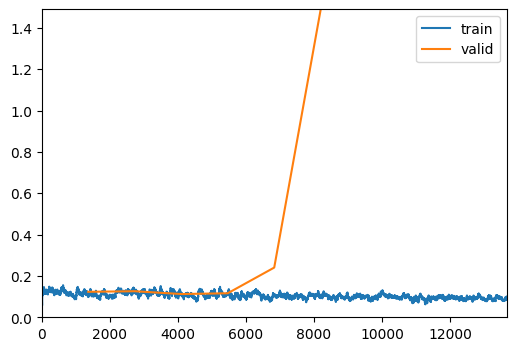

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.11246427148580551.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 8 with valid_loss value: 0.10512750595808029.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

2 horas 33 minutos.

### Deit

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Deit')  
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(384), # Solo funciona con este tamaño
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=8)

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h solo en la primera época, por lo que se espera que tarde 10 horas.

## Balanceo

In [6]:
df

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54701,1,9973,1729524723,R,MLO,43.0,0,0,0,1.0,0,C,49,False
54702,1,9989,63473691,L,MLO,60.0,0,0,0,NaN,0,C,216,False
54703,1,9989,1078943060,L,CC,60.0,0,0,0,NaN,0,C,216,False
54704,1,9989,398038886,R,MLO,60.0,0,0,0,0.0,0,C,216,True


In [7]:
tam = df.loc[df["cancer"] == 1]["patient_id"].unique().size

In [8]:
X = df.loc[::, df.columns.drop("cancer")].copy()
y = df.loc[::, "cancer"].copy()

In [9]:
y.value_counts()

0    53548
1     1158
Name: cancer, dtype: int64

Los datos están claramente desbalanceados. Se va a escoger al azar los elementos de la clase mayoritaria para entrenar a los modelos.

In [10]:
np.random.seed(0)
patients = np.random.choice(df.loc[df["cancer"] == 0]["patient_id"], tam)
patients = np.concatenate((patients, df.loc[df["cancer"] == 1]["patient_id"].unique()))
patients.size

972

In [11]:
dfb = df.loc[df["patient_id"].isin(patients)].copy()

In [12]:
dfb

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
87,1,10130,388811999,L,MLO,71.0,1,1,1,0.0,0,B,49,False
88,1,10130,613462606,L,CC,71.0,1,1,1,0.0,0,B,49,False
89,1,10130,1360338805,L,CC,71.0,1,1,1,0.0,0,B,49,False
90,1,10130,1672636630,L,MLO,71.0,1,1,1,0.0,0,B,49,False
91,1,10130,1013166704,R,CC,71.0,0,0,0,NaN,0,B,49,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54598,2,9851,1945262248,R,MLO,58.0,0,0,0,NaN,0,NaN,48,False
54625,1,9894,564726178,L,CC,50.0,0,1,0,0.0,0,B,49,True
54626,1,9894,942623950,L,MLO,50.0,0,1,0,0.0,0,B,49,True
54627,1,9894,1991772614,R,CC,50.0,0,1,0,0.0,0,B,49,True


In [13]:
import os
import shutil

p_under = path/"undersampled"

if not os.path.isdir(p_under):
    os.mkdir(p_under)

for index, row in dfb.iterrows():
    patient = row["patient_id"]
    shutil.copytree(imagesPath/str(patient), p_under/str(patient), dirs_exist_ok=True)

## Modelos undersampling

In [14]:
def cadena2(path):
    partes = path.split(os.path.sep)
    return partes[0][:-4]

def label_func2(fname):
    return dfb.loc[dfb['image_id'] == int(cadena2(fname.name))]['cancer'].values[0]

### Resnet50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=32)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 347MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.151652,0.842945,0.588428,0.282675,0.397436,0.330373,01:17


Better model found at epoch 0 with valid_loss value: 0.8429452180862427.


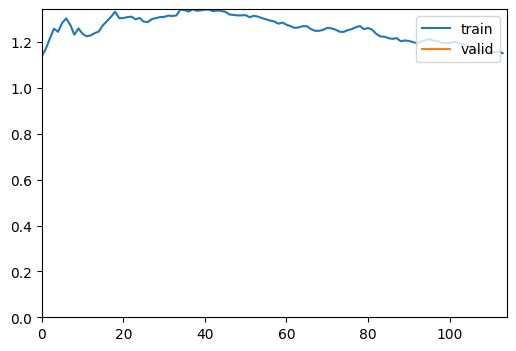

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.827866,0.650811,0.730349,0.348837,0.064103,0.108303,01:27
1,0.761209,0.624746,0.731441,0.250000,0.025641,0.046512,01:27
2,0.742217,0.645039,0.729258,0.250000,0.029915,0.053435,01:26
3,0.725854,0.678734,0.707424,0.242424,0.068376,0.106667,01:27
4,0.693442,0.599018,0.721616,0.352113,0.106838,0.163934,01:26
5,0.683520,0.630916,0.745633,0.538462,0.029915,0.056680,01:27
6,0.654430,0.540075,0.752183,0.537634,0.213675,0.305810,01:26
7,0.600882,0.540813,0.771834,0.790698,0.145299,0.245487,01:27
8,0.583713,0.651750,0.751092,0.875000,0.029915,0.057851,01:26
9,0.583468,0.513883,0.770742,0.662162,0.209402,0.318182,01:26


Better model found at epoch 0 with valid_loss value: 0.650810956954956.


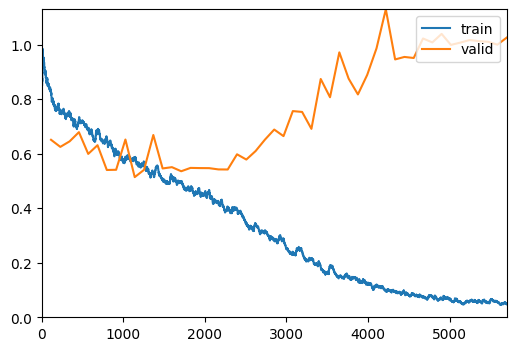

Better model found at epoch 1 with valid_loss value: 0.6247456669807434.
Better model found at epoch 4 with valid_loss value: 0.5990183353424072.
Better model found at epoch 6 with valid_loss value: 0.5400754809379578.
Better model found at epoch 9 with valid_loss value: 0.5138833522796631.


In [ ]:
learn.fine_tune(50, base_lr=1e-3)

Ha tardado 1h 15 mins.

### EfficientNet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='efficientNetB3')
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-cf984f9c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-cf984f9c.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 123MB/s]


In [ ]:
learn.fine_tune(20, base_lr=1e-3)

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time


FileNotFoundError: ignored

No sé por qué no funciona.

### ConvNext

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='ConvNext')
]

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:04<00:00, 78.8MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.023241,0.730419,0.708515,0.346667,0.106557,0.163009,03:13


Better model found at epoch 0 with valid_loss value: 0.7304185628890991.


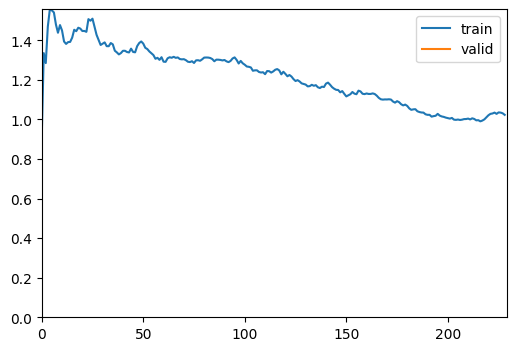

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.773583,0.671381,0.725983,0.418605,0.073770,0.125436,04:02
1,0.793189,0.800943,0.729258,0.375000,0.024590,0.046154,04:01
2,0.730452,0.587134,0.722707,0.428571,0.122951,0.191083,04:01
3,0.695664,0.555251,0.728166,0.481481,0.266393,0.343008,04:03
4,0.651280,0.562009,0.733624,0.500000,0.053279,0.096296,04:02
5,0.632060,0.551328,0.727074,0.479452,0.286885,0.358974,04:01
6,0.576959,0.525876,0.763100,0.642105,0.250000,0.359882,04:00
7,0.569786,0.515760,0.754367,0.672727,0.151639,0.247492,04:00
8,0.571676,0.514738,0.752183,0.644068,0.155738,0.250825,04:00
9,0.520747,0.514601,0.762009,0.601562,0.315574,0.413978,04:00


Better model found at epoch 0 with valid_loss value: 0.6713812351226807.


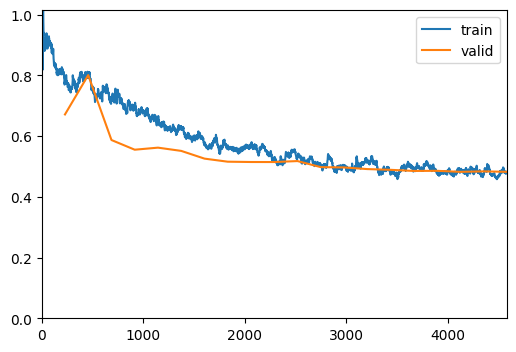

Better model found at epoch 2 with valid_loss value: 0.5871343016624451.
Better model found at epoch 3 with valid_loss value: 0.555250883102417.
Better model found at epoch 5 with valid_loss value: 0.5513279438018799.
Better model found at epoch 6 with valid_loss value: 0.525875985622406.
Better model found at epoch 7 with valid_loss value: 0.5157603621482849.
Better model found at epoch 8 with valid_loss value: 0.5147382616996765.
Better model found at epoch 9 with valid_loss value: 0.5146010518074036.
Better model found at epoch 11 with valid_loss value: 0.49789464473724365.
Better model found at epoch 12 with valid_loss value: 0.49681660532951355.
Better model found at epoch 13 with valid_loss value: 0.49144014716148376.
Better model found at epoch 14 with valid_loss value: 0.4890037477016449.
Better model found at epoch 15 with valid_loss value: 0.48525822162628174.
Better model found at epoch 17 with valid_loss value: 0.48232975602149963.


In [ ]:
learn.fine_tune(20, base_lr=1e-3)

Ha tardado 1 hora y 24 minutos.

### Hrnet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='Hrnet')
]

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.923704,0.720100,0.684498,0.274390,0.209302,0.237467,04:44


Better model found at epoch 0 with valid_loss value: 0.7200996279716492.


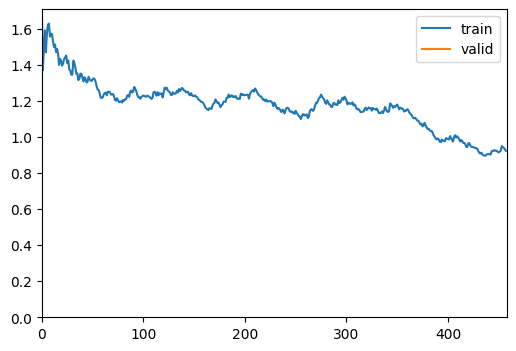

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.727161,0.603322,0.733624,0.236364,0.060465,0.096296,06:16
1,0.669366,0.562024,0.730349,0.250000,0.074419,0.114695,06:15
2,0.676632,0.604640,0.756550,0.300000,0.027907,0.051064,06:14
3,0.658978,0.602354,0.710699,0.284483,0.153488,0.199396,06:13
4,0.626476,0.566752,0.746725,0.257143,0.041860,0.072000,06:13
5,0.600874,0.568481,0.741266,0.322581,0.093023,0.144404,06:15
6,0.589978,0.567358,0.725983,0.290698,0.116279,0.166113,06:15
7,0.626047,0.562547,0.747817,0.233333,0.032558,0.057143,06:15
8,0.596619,0.644111,0.615721,0.290520,0.441860,0.350554,06:16
9,0.578139,0.561068,0.745633,0.381579,0.134884,0.199313,06:16


Better model found at epoch 0 with valid_loss value: 0.6033217906951904.


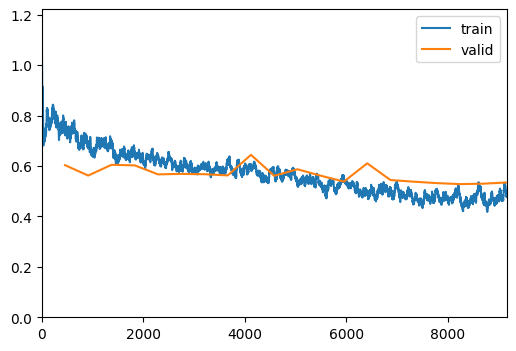

Better model found at epoch 1 with valid_loss value: 0.5620241165161133.
Better model found at epoch 9 with valid_loss value: 0.5610678195953369.
Better model found at epoch 12 with valid_loss value: 0.5381888747215271.
Better model found at epoch 15 with valid_loss value: 0.5376722812652588.
Better model found at epoch 16 with valid_loss value: 0.5319600105285645.
Better model found at epoch 17 with valid_loss value: 0.5280985832214355.


In [ ]:
learn.fine_tune(20, base_lr=1e-3)

2 horas, 10 minutos.

### Deit

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Deit')  
]

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.861480,0.720282,0.703057,0.252336,0.123288,0.165644,01:43


Better model found at epoch 0 with valid_loss value: 0.7202824950218201.


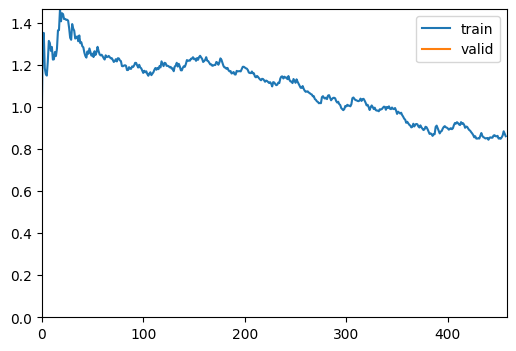

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.770299,0.596661,0.718341,0.298969,0.132420,0.183544,02:17
1,0.672093,0.592862,0.741266,0.312500,0.068493,0.112360,02:16
2,0.680604,0.539482,0.758734,0.482143,0.123288,0.196364,02:16
3,0.664912,0.547363,0.751092,0.455446,0.210046,0.287500,02:15
4,0.554376,0.536831,0.759825,0.495146,0.232877,0.316770,02:17
5,0.610224,0.507385,0.766376,0.534247,0.178082,0.267123,02:16
6,0.562128,0.500867,0.768559,0.552239,0.168950,0.258741,02:16
7,0.562276,0.517470,0.767467,0.529412,0.246575,0.336449,02:16
8,0.527251,0.499503,0.770742,0.542056,0.264840,0.355828,02:16
9,0.518162,0.482241,0.784935,0.637500,0.232877,0.341137,02:15


Better model found at epoch 0 with valid_loss value: 0.5966611504554749.


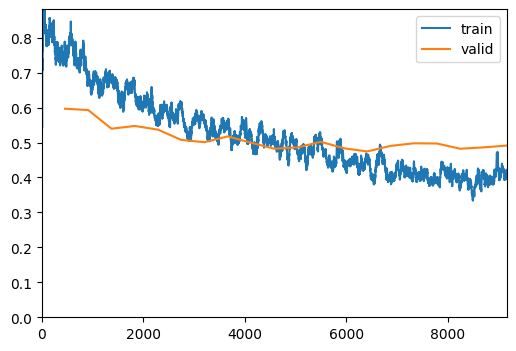

Better model found at epoch 1 with valid_loss value: 0.5928617715835571.
Better model found at epoch 2 with valid_loss value: 0.5394816398620605.
Better model found at epoch 4 with valid_loss value: 0.536830723285675.
Better model found at epoch 5 with valid_loss value: 0.5073848366737366.
Better model found at epoch 6 with valid_loss value: 0.5008671283721924.
Better model found at epoch 8 with valid_loss value: 0.49950316548347473.
Better model found at epoch 9 with valid_loss value: 0.48224106431007385.
Better model found at epoch 13 with valid_loss value: 0.4744536876678467.


In [ ]:
learn.fine_tune(20, base_lr=1e-3)

47 minutos 23 segundos.

## Balanceo v2

Esta vez se a a probar a balancear por imagenes en vez de por pacientes a ver qué ocurre.

In [24]:
np.random.seed(0)
images = np.random.choice(df.loc[df["cancer"] == 0]["image_id"], tam)
images = np.concatenate((images, np.random.choice(df.loc[df["cancer"] == 1]["image_id"], tam)))
images.size

972

In [27]:
dfb2 = df.loc[df["image_id"].isin(images)].copy()

In [28]:
dfb2["cancer"].value_counts()

0    484
1    405
Name: cancer, dtype: int64

In [40]:
import os
import shutil

p_under2 = path/"undersampled_v2"

if not os.path.isdir(p_under2):
    os.mkdir(p_under2)

for index, row in dfb2.iterrows():
    patient = row["patient_id"]
    if not os.path.isdir(p_under2/str(patient)):
        os.mkdir(p_under2/str(patient))
    image = row["image_id"]
    src = imagesPath/str(patient)/(str(image)+'.jpg')
    dst = p_under2/str(patient)/(str(image)+'.jpg')
    shutil.copyfile(src, dst)

## Modelos undersampling v2

In [45]:
def cadena3(path):
    partes = path.split(os.path.sep)
    return partes[0][:-4]

def label_func3(fname):
    return dfb2.loc[dfb2['image_id'] == int(cadena3(fname.name))]['cancer'].values[0]

### Resnet50

In [46]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [47]:
dls = db.dataloaders(p_under2, bs=32)

In [48]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='modelResnet50')
]

In [49]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.384948,1.165911,0.587571,0.600000,0.080000,0.141176,00:18


Better model found at epoch 0 with valid_loss value: 1.1659107208251953.


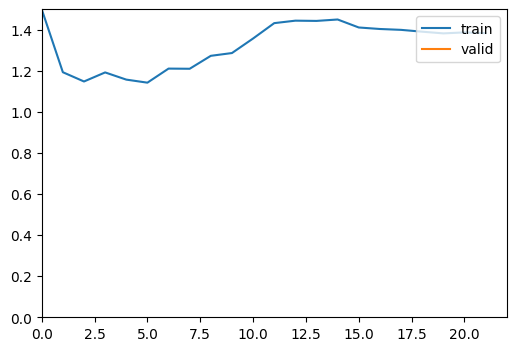

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.299031,0.831744,0.615819,0.550725,0.506667,0.527778,00:17
1,1.186186,1.011893,0.581921,0.521739,0.160000,0.244898,00:17
2,1.142759,0.871727,0.548023,0.457627,0.360000,0.402985,00:18
3,1.119338,0.813896,0.553672,0.476744,0.546667,0.509317,00:17
4,1.112104,0.859381,0.553672,0.462963,0.333333,0.387597,00:17
5,1.096199,0.868610,0.531073,0.456522,0.560000,0.502994,00:18
6,1.036263,0.894617,0.536723,0.463918,0.600000,0.523256,00:17
7,1.029429,1.123829,0.525424,0.421053,0.320000,0.363636,00:17
8,0.992275,1.431366,0.502825,0.451852,0.813333,0.580952,00:18
9,0.977772,1.038898,0.581921,0.509434,0.360000,0.421875,00:17


Better model found at epoch 0 with valid_loss value: 0.8317438960075378.


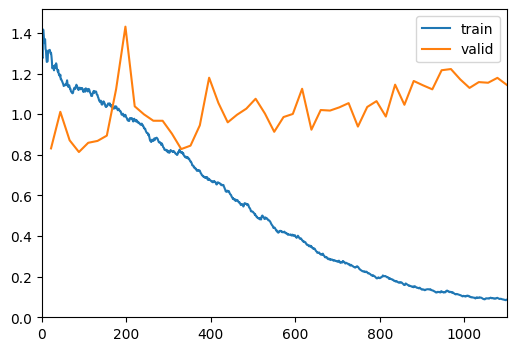

Better model found at epoch 3 with valid_loss value: 0.8138956427574158.


In [50]:
learn.fine_tune(50, base_lr=1e-3)

Ha tardado 15 minutos y medio.

### EfficientNet

In [51]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [52]:
dls = db.dataloaders(p_under2, bs=16)

In [53]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='efficientNetB3')
]

In [54]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-cf984f9c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-cf984f9c.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 179MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.582110,1.123413,0.525424,0.444444,0.480000,0.461538,00:23


Better model found at epoch 0 with valid_loss value: 1.1234132051467896.


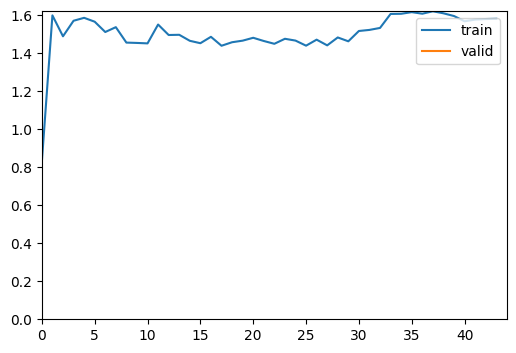

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time


In [55]:
learn.fine_tune(20, base_lr=1e-3)

Ha parado en la primera época al no mejorar.

### ConvNext

In [56]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [57]:
dls = db.dataloaders(p_under2, bs=16)

In [58]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='ConvNext')
]

In [59]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:03<00:00, 91.7MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.231568,0.782821,0.559322,0.480000,0.480000,0.480000,00:40


Better model found at epoch 0 with valid_loss value: 0.7828214168548584.


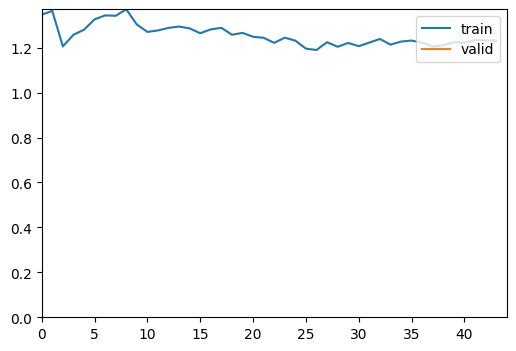

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.084769,0.742897,0.615819,0.577778,0.346667,0.433333,00:49
1,1.070697,0.717893,0.621469,0.586957,0.360000,0.446281,00:50
2,1.088208,0.746169,0.604520,0.551020,0.360000,0.435484,00:49
3,1.102019,0.749636,0.598870,0.526316,0.533333,0.529801,00:50
4,1.071842,0.678638,0.610169,0.553571,0.413333,0.473282,00:50
5,1.053461,0.649676,0.621469,0.550000,0.586667,0.567742,00:49
6,0.981557,0.681801,0.638418,0.559140,0.693333,0.619048,00:49
7,0.932542,0.808192,0.587571,0.507576,0.893333,0.647343,00:50
8,0.873722,0.679669,0.593220,0.518987,0.546667,0.532468,00:50
9,0.844428,0.675242,0.593220,0.516129,0.640000,0.571429,00:50


Better model found at epoch 0 with valid_loss value: 0.7428972721099854.


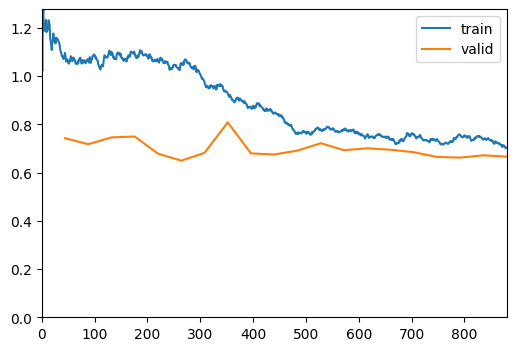

Better model found at epoch 1 with valid_loss value: 0.7178930044174194.
Better model found at epoch 4 with valid_loss value: 0.6786381602287292.
Better model found at epoch 5 with valid_loss value: 0.6496759057044983.


In [60]:
learn.fine_tune(20, base_lr=1e-3)

Ha tardado 17 minutos y medio.

### Hrnet

In [61]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [62]:
dls = db.dataloaders(p_under2, bs=8)

In [63]:
callbacks = [
    ShowGraphCallback(),
    TerminateOnNaNCallback(),
    SaveModelCallback(fname='Hrnet')
]

In [64]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.528581,1.519709,0.548023,0.475248,0.640000,0.545455,00:57


Better model found at epoch 0 with valid_loss value: 1.5197089910507202.


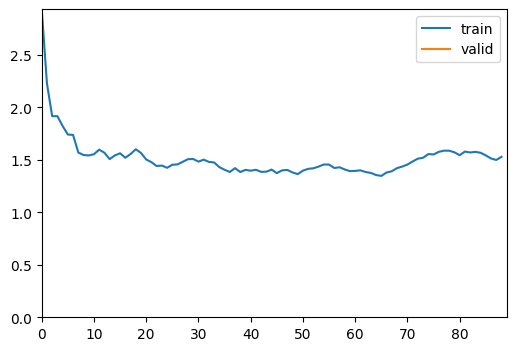

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.479229,1.062707,0.536723,0.453333,0.453333,0.453333,01:14
1,1.351647,1.098070,0.519774,0.445652,0.546667,0.491018,01:15
2,1.269234,0.994275,0.542373,0.437500,0.280000,0.341463,01:15
3,1.149899,1.049921,0.576271,0.500000,0.240000,0.324324,01:15
4,1.115452,1.130907,0.508475,0.357143,0.200000,0.256410,01:15
5,1.059627,0.844354,0.610169,0.578947,0.293333,0.389381,01:15
6,0.972446,0.809662,0.536723,0.455696,0.480000,0.467532,01:15
7,0.878802,0.825900,0.502825,0.444444,0.693333,0.541667,01:15
8,0.850428,0.967741,0.491525,0.448276,0.866667,0.590909,01:15
9,0.816284,0.797588,0.564972,0.491803,0.800000,0.609137,01:15


Better model found at epoch 0 with valid_loss value: 1.0627065896987915.


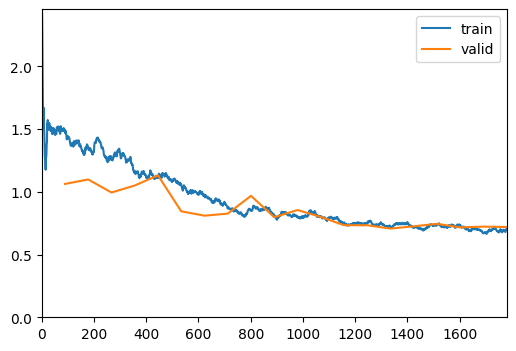

Better model found at epoch 2 with valid_loss value: 0.9942750334739685.
Better model found at epoch 5 with valid_loss value: 0.8443536162376404.
Better model found at epoch 6 with valid_loss value: 0.8096622824668884.
Better model found at epoch 9 with valid_loss value: 0.7975883483886719.
Better model found at epoch 12 with valid_loss value: 0.7337167263031006.
Better model found at epoch 13 with valid_loss value: 0.733341634273529.
Better model found at epoch 14 with valid_loss value: 0.7066596746444702.


In [65]:
learn.fine_tune(20, base_lr=1e-3)

26 minutos.

### Deit

In [66]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [67]:
dls = db.dataloaders(p_under2, bs=8)

In [68]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Deit')  
]

In [69]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.193711,0.824149,0.581921,0.507246,0.466667,0.486111,00:22


Better model found at epoch 0 with valid_loss value: 0.8241488933563232.


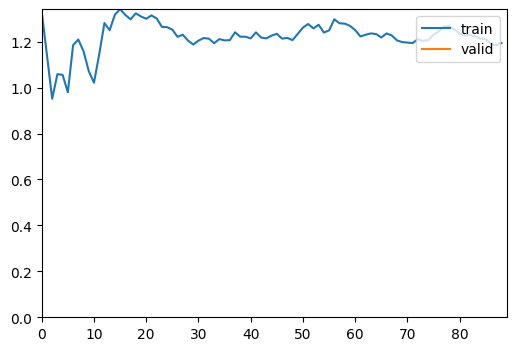

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.219451,0.709470,0.615819,0.553846,0.480000,0.514286,00:28
1,1.060425,0.720685,0.632768,0.573529,0.520000,0.545455,00:28
2,1.090102,0.763756,0.564972,0.481481,0.346667,0.403101,00:29
3,0.998641,0.790999,0.570621,0.491525,0.386667,0.432836,00:29
4,1.005020,0.830038,0.604520,0.537313,0.480000,0.507042,00:29
5,0.992207,0.826144,0.559322,0.472727,0.346667,0.400000,00:29
6,0.940065,0.822304,0.593220,0.533333,0.320000,0.400000,00:28
7,0.933666,0.776488,0.610169,0.551724,0.426667,0.481203,00:28
8,0.789557,0.773879,0.627119,0.567164,0.506667,0.535211,00:29
9,0.744244,0.742785,0.627119,0.558442,0.573333,0.565789,00:30


Better model found at epoch 0 with valid_loss value: 0.709470272064209.


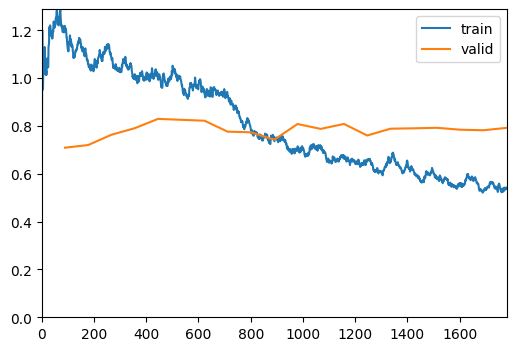

In [70]:
learn.fine_tune(20, base_lr=1e-3)

10 minutos.

## Procesamiento de datos

In [ ]:
dfb

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
87,1,10130,388811999,L,MLO,71.0,1,1,1,0.0,0,B,49,False
88,1,10130,613462606,L,CC,71.0,1,1,1,0.0,0,B,49,False
89,1,10130,1360338805,L,CC,71.0,1,1,1,0.0,0,B,49,False
90,1,10130,1672636630,L,MLO,71.0,1,1,1,0.0,0,B,49,False
91,1,10130,1013166704,R,CC,71.0,0,0,0,NaN,0,B,49,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54598,2,9851,1945262248,R,MLO,58.0,0,0,0,NaN,0,NaN,48,False
54625,1,9894,564726178,L,CC,50.0,0,1,0,0.0,0,B,49,True
54626,1,9894,942623950,L,MLO,50.0,0,1,0,0.0,0,B,49,True
54627,1,9894,1991772614,R,CC,50.0,0,1,0,0.0,0,B,49,True


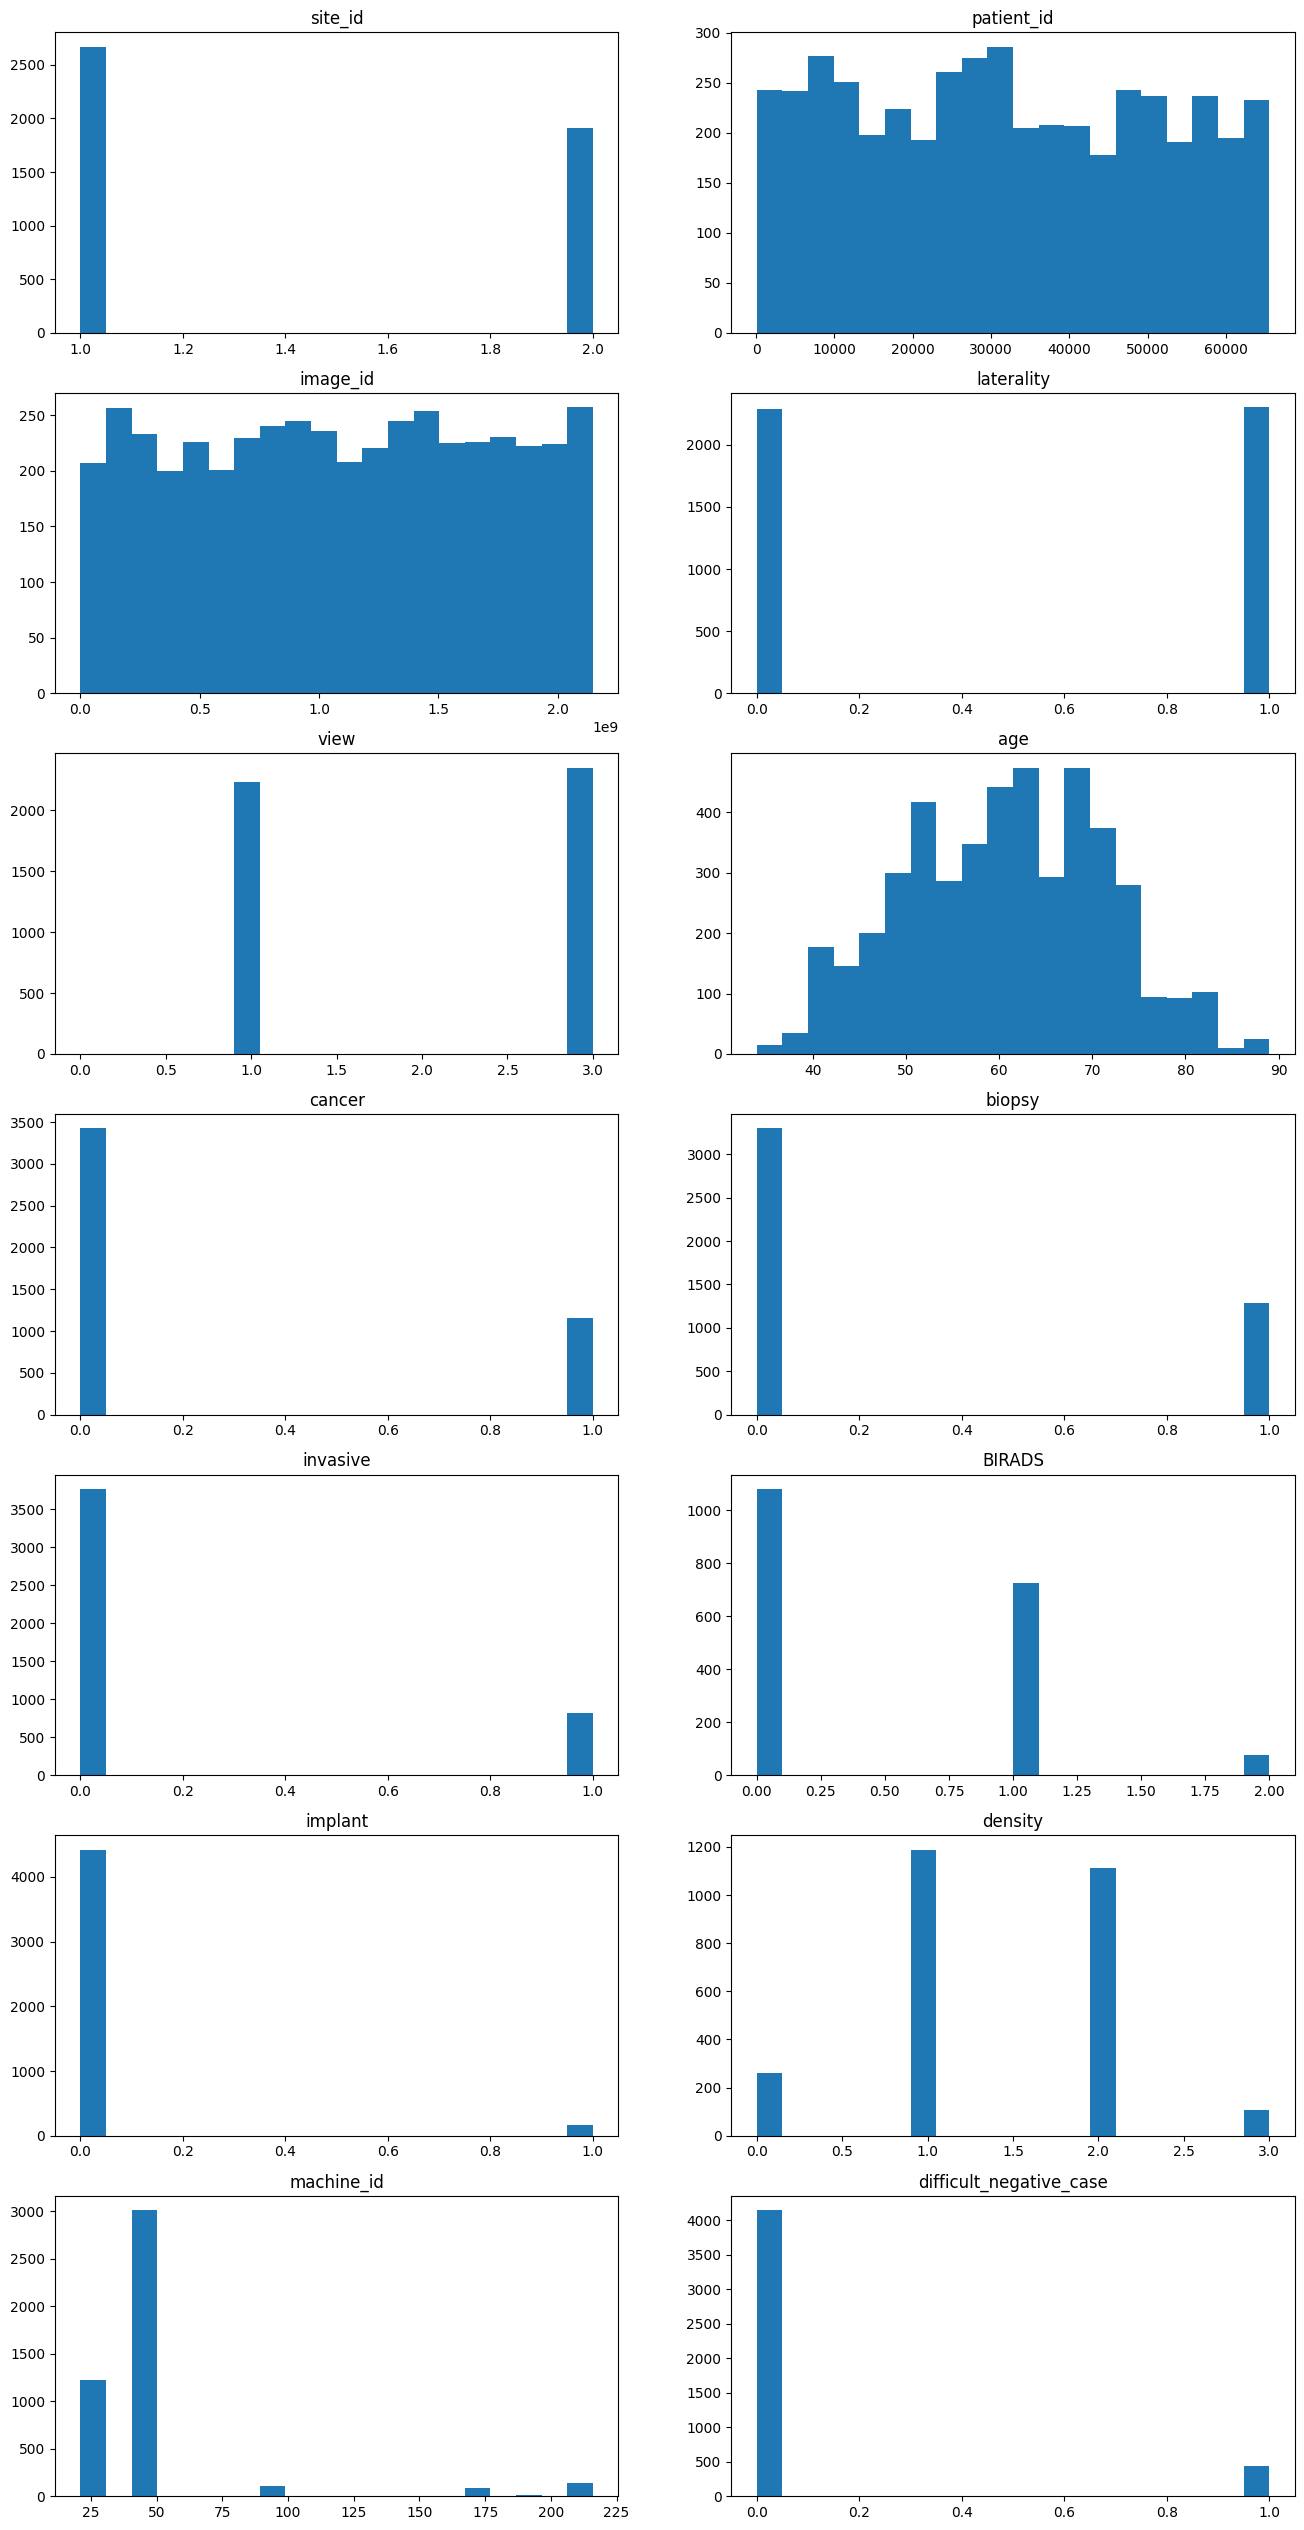

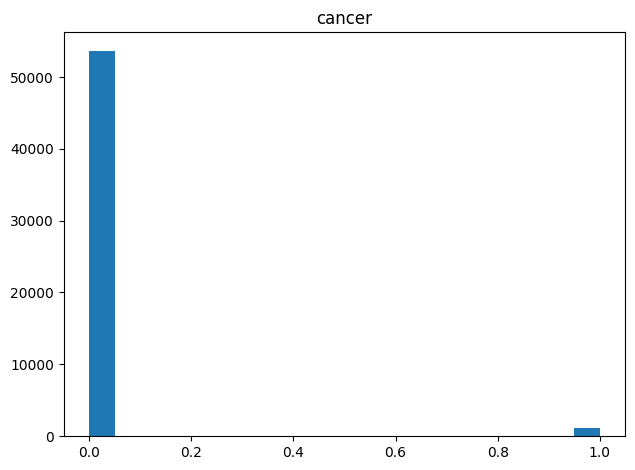

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
dfb2 = dfb.copy()
enc = OrdinalEncoder()
dfb2[["laterality","view","density","difficult_negative_case"]] = enc.fit_transform(dfb2[["laterality","view","density","difficult_negative_case"]])
fig, axes = plt.subplots(7, 2, figsize = (16, 32))
axes[0,0].hist(dfb2["site_id"].values, bins = 20)
axes[0,0].set_title("site_id")
axes[0,1].hist(dfb2["patient_id"].values, bins = 20)
axes[0,1].set_title("patient_id")
axes[1,0].hist(dfb2["image_id"].values, bins = 20)
axes[1,0].set_title("image_id")
axes[1,1].hist(dfb2["laterality"].values, bins = 20)
axes[1,1].set_title("laterality")
axes[2,0].hist(dfb2["view"].values, bins = 20)
axes[2,0].set_title("view")
axes[2,1].hist(dfb2["age"].values, bins = 20)
axes[2,1].set_title("age")
axes[3,0].hist(dfb2["cancer"].values, bins = 20)
axes[3,0].set_title("cancer")
axes[3,1].hist(dfb2["biopsy"].values, bins = 20)
axes[3,1].set_title("biopsy")
axes[4,0].hist(dfb2["invasive"].values, bins = 20)
axes[4,0].set_title("invasive")
axes[4,1].hist(dfb2["BIRADS"].values, bins = 20)
axes[4,1].set_title("BIRADS")
axes[5,0].hist(dfb2["implant"].values, bins = 20)
axes[5,0].set_title("implant")
axes[5,1].hist(dfb2["density"].values, bins = 20)
axes[5,1].set_title("density")
axes[6,0].hist(dfb2["machine_id"].values, bins = 20)
axes[6,0].set_title("machine_id")
axes[6,1].hist(dfb2["difficult_negative_case"].values, bins = 20)
axes[6,1].set_title("difficult_negative_case")
plt.show()

plt.figure(figsize = (7.25, 5.25))
plt.title("cancer")
plt.hist(y.values, bins = 20)
plt.show()